# Bank Marketing Campaign: Will the Client Subscribe?

A Portuguese bank ran phone-based marketing campaigns to sell **term deposits** — where a client locks money away for a fixed period in exchange for guaranteed interest.

Your goal: predict which clients will say **yes** to a term deposit, so the bank can target its calls more efficiently.

## What makes this project different
- **Tabular + neural network** — you'll build a PyTorch MLP for non-image data for the first time
- **Mini-batch training** — instead of feeding all data at once, you'll learn to use `DataLoader`
- **Required normalization** — `StandardScaler` is optional for trees but *required* for neural nets
- **Honest comparison** — sklearn baselines trained first, then see if the neural net can beat them

## What you'll learn
- How to build a PyTorch `Dataset` and `DataLoader` for tabular data
- The full mini-batch training loop with loss/accuracy curves
- Why `BatchNorm` and `Dropout` make neural nets more robust
- When a neural network beats classical ML — and when it doesn't

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import urllib.request
import zipfile
import ssl

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Detect best available device
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print(f'Libraries loaded!')
print(f'Using device: {device}')

Libraries loaded!
Using device: mps


## Step 1: Load the Data

The **Bank Marketing dataset** from UCI tracks ~41,000 phone calls made by a Portuguese bank. Each row is one client contact.

**Features include:**
- *Client info*: age, job, marital status, education, credit default, housing/personal loans
- *Last contact*: communication type, month, day, call duration
- *Campaign*: number of contacts, days since last contact, previous campaign outcome
- *Economic context*: employment rate, consumer price index, consumer confidence, Euribor rate

**Target:** `y` — did the client subscribe to a term deposit? (`yes`/`no`)

Note: European datasets often use `;` as a separator instead of `,`.

In [2]:
data_dir = Path.home() / 'LocalAI' / 'data' / 'bank_marketing'
data_dir.mkdir(parents=True, exist_ok=True)

csv_path = data_dir / 'bank-additional' / 'bank-additional-full.csv'

if not csv_path.exists():
    print('Downloading dataset (~500KB)...')
    url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip'
    zip_path = data_dir / 'bank-additional.zip'
    # UCI's SSL cert is expired — bypass verification for this known dataset
    ssl._create_default_https_context = ssl._create_unverified_context
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(data_dir)
    print('Downloaded!')
else:
    print('Data already downloaded.')

df = pd.read_csv(csv_path, sep=';')
print(f'Shape: {df.shape}')
df.head()

Data already downloaded.
Shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Step 2: Explore the Data

Before modeling, get oriented. Pay attention to:
1. How many clients actually subscribed? (expect it to be imbalanced)
2. Which features are numeric vs. categorical?
3. How many `unknown` values exist?

In [3]:
print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
print()
print(df.dtypes)
print()

# 'unknown' is this dataset's way of encoding missing values
# include both 'object' (pandas 2/3) and 'str' (pandas 4) to avoid deprecation warning
print('Unknown value counts per column:')
for col in df.select_dtypes(include=['object', 'str']).columns:
    n = (df[col] == 'unknown').sum()
    if n > 0:
        print(f'  {col:<20} {n:>5,}  ({n/len(df):.1%})')

Rows: 41,188
Columns: 21

age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Unknown value counts per column:
  job                    330  (0.8%)
  marital                 80  (0.2%)
  education            1,731  (4.2%)
  default              8,597  (20.9%)
  housing                990  (2.4%)
  loan                   990  (2.4%)


Subscription rate: 11.3%
Class counts:
y
no     36548
yes     4640
Name: count, dtype: int64


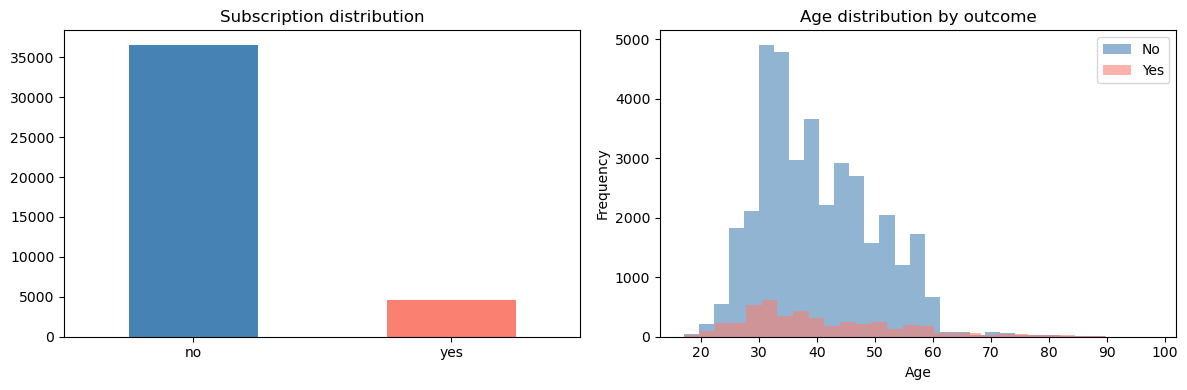


~11% positive rate — same imbalance problem as hospital readmission.
A model that always predicts "no" would be 89% accurate but useless.


In [4]:
# Class distribution
subscription_rate = (df['y'] == 'yes').mean()
print(f'Subscription rate: {subscription_rate:.1%}')
print('Class counts:')
print(df['y'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['y'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title('Subscription distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

# Age distribution by outcome
df[df['y'] == 'no']['age'].plot(kind='hist', bins=30, alpha=0.6, ax=axes[1], label='No', color='steelblue')
df[df['y'] == 'yes']['age'].plot(kind='hist', bins=30, alpha=0.6, ax=axes[1], label='Yes', color='salmon')
axes[1].set_title('Age distribution by outcome')
axes[1].set_xlabel('Age')
axes[1].legend()

plt.tight_layout()
plt.show()

print()
print('~11% positive rate — same imbalance problem as hospital readmission.')
print('A model that always predicts "no" would be 89% accurate but useless.')

## Step 3: Clean and Encode

Neural networks require everything to be numeric. Unlike trees (which can handle categories natively in some implementations), an MLP only understands numbers.

**Key decisions:**
- `unknown` values → treat as their own category (not missing), so they survive one-hot encoding
- `pdays` = 999 means "never contacted before" — replace it with a binary indicator
- `duration` is a **data leak**: call duration is only known *after* the call ends, so you can't use it to decide who to call. We'll keep it here to match standard tutorials, but note this caveat.
- After encoding, apply `StandardScaler` — mandatory for neural nets, harmless for trees

**Why StandardScaler matters for neural networks:**  
Net weights start near 0 and learn via gradient descent. If `age` ranges 18–95 and `euribor3m` ranges 0.6–5.0 while `nr.employed` ranges 4963–5228, gradients get dominated by the large-scale features. Scaling to zero mean / unit variance fixes this.

In [5]:
data = df.copy()

# Binary target
data['y'] = (data['y'] == 'yes').astype(int)

# pdays=999 means 'never previously contacted' — encode that signal explicitly
data['previously_contacted'] = (data['pdays'] != 999).astype(int)
data = data.drop(columns=['pdays'])

# One-hot encode all categorical columns
# 'unknown' becomes its own dummy column — no information is lost
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
            'contact', 'month', 'day_of_week', 'poutcome']
data = pd.get_dummies(data, columns=cat_cols)

print(f'Shape after encoding: {data.shape}')
print(f'All dtypes numeric: {(data.dtypes != object).all()}')
data.head()

Shape after encoding: (41188, 64)
All dtypes numeric: True


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
0,56,261,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,False,False,False,True,False,False,False,False,True,False
1,57,149,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,False,False,False,True,False,False,False,False,True,False
2,37,226,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,False,False,False,True,False,False,False,False,True,False
3,40,151,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,False,False,False,True,False,False,False,False,True,False
4,56,307,1,0,1.1,93.994,-36.4,4.857,5191.0,0,...,False,False,False,True,False,False,False,False,True,False


In [6]:
X = data.drop(columns=['y'])
y = data['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fit scaler on training data only — never fit on test data
# (fitting on test data would leak test statistics into training)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training samples: {len(X_train):,}')
print(f'Test samples:     {len(X_test):,}')
print(f'Features:         {X_train.shape[1]}')
print(f'Positive rate in test: {y_test.mean():.1%}')

Training samples: 32,950
Test samples:     8,238
Features:         63
Positive rate in test: 11.3%


## Step 4: sklearn Baseline

Always train a baseline before touching a neural network. If your MLP can't beat Logistic Regression, something is wrong — or the data just doesn't need a net.

`class_weight='balanced'` handles the imbalance the same way as the readmission project.

In [7]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
rf_preds = rf.predict(X_test_scaled)

print('Baselines trained!')

for name, preds in [('Logistic Regression', lr_preds), ('Random Forest', rf_preds)]:
    print(f'\n=== {name} ===')
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))

Baselines trained!

=== Logistic Regression ===
              precision    recall  f1-score   support

          No       0.99      0.86      0.92      7310
         Yes       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238


=== Random Forest ===
              precision    recall  f1-score   support

          No       0.93      0.98      0.95      7310
         Yes       0.71      0.42      0.52       928

    accuracy                           0.92      8238
   macro avg       0.82      0.70      0.74      8238
weighted avg       0.90      0.92      0.91      8238



## Step 5: Build the Neural Network

### The architecture: a Multi-Layer Perceptron (MLP)

```
Input (54 features)
    → Linear(54 → 64) → BatchNorm → ReLU → Dropout(0.3)
    → Linear(64 → 32) → BatchNorm → ReLU → Dropout(0.2)
    → Linear(32 → 1)   ← raw logit (sigmoid applied in loss)
```

**BatchNorm1d**: normalizes activations within each mini-batch — stabilizes training and lets you use higher learning rates.  
**Dropout**: randomly zeros out a fraction of neurons during training — forces the network to learn redundant representations and prevents overfitting.

### From all-at-once to mini-batches

The Iris example in `02_deep_learning/01_pytorch_intro.ipynb` fed all 120 training samples in one shot. With 33k rows, that still fits in memory — but mini-batching is better practice:
- More gradient updates per epoch (one per batch, not one total)
- The noise from different batches helps escape local minima
- Scales to datasets too large to fit in RAM

`DataLoader` handles the batching and shuffling automatically.

In [8]:
class BankDataset(Dataset):
    """Wraps numpy arrays so DataLoader can batch them."""
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = BankDataset(X_train_scaled, y_train)
test_dataset  = BankDataset(X_test_scaled,  y_test)

# shuffle=True for training — different batch order each epoch
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

print(f'Training batches per epoch: {len(train_loader)}')
print(f'Each epoch processes {len(train_loader) * 256:,} samples')

Training batches per epoch: 129
Each epoch processes 33,024 samples


In [9]:
class BankMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1),  # single output: raw logit
        )

    def forward(self, x):
        return self.network(x).squeeze(1)


input_size = X_train_scaled.shape[1]
model = BankMLP(input_size).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\nInput features: {input_size}')
print(f'Total parameters: {total_params:,}')

BankMLP(
  (network): Sequential(
    (0): Linear(in_features=63, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Input features: 63
Total parameters: 6,401


## Step 6: Train

The training loop is the same pattern as the Iris example — `zero_grad → forward → loss → backward → step` — but now it runs over batches and tracks both train and validation metrics each epoch.

**`BCEWithLogitsLoss`**: combines sigmoid + binary cross-entropy in one numerically stable operation. This is the standard loss for binary classification in PyTorch.

**`pos_weight`**: equivalent to `class_weight='balanced'` in sklearn. Setting it to ~8 tells the loss to penalize missing a subscriber 8× more than a false alarm, which compensates for the 11% positive rate.

In [10]:
# pos_weight ~ (negative count / positive count) to counteract imbalance
pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()], dtype=torch.float32).to(device)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.parameters(), lr=1e-3)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
n_epochs = 50

for epoch in range(n_epochs):
    # --- Training ---
    model.train()
    batch_losses, correct, total = [], 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
        preds    = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == y_batch).sum().item()
        total   += len(y_batch)

    train_losses.append(np.mean(batch_losses))
    train_accs.append(correct / total)

    # --- Validation ---
    model.eval()
    val_batch_losses, val_correct, val_total = [], 0, 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)
            val_batch_losses.append(loss.item())
            preds       = (torch.sigmoid(logits) > 0.5).float()
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    val_losses.append(np.mean(val_batch_losses))
    val_accs.append(val_correct / val_total)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{n_epochs} | '
              f'Train Loss: {train_losses[-1]:.4f} | '
              f'Val Loss: {val_losses[-1]:.4f} | '
              f'Val Acc: {val_accs[-1]:.1%}')

Epoch  10/50 | Train Loss: 0.5082 | Val Loss: 0.4998 | Val Acc: 83.7%
Epoch  20/50 | Train Loss: 0.4937 | Val Loss: 0.4969 | Val Acc: 84.4%
Epoch  30/50 | Train Loss: 0.4786 | Val Loss: 0.5019 | Val Acc: 83.9%
Epoch  40/50 | Train Loss: 0.4631 | Val Loss: 0.5121 | Val Acc: 85.1%
Epoch  50/50 | Train Loss: 0.4528 | Val Loss: 0.5165 | Val Acc: 85.4%


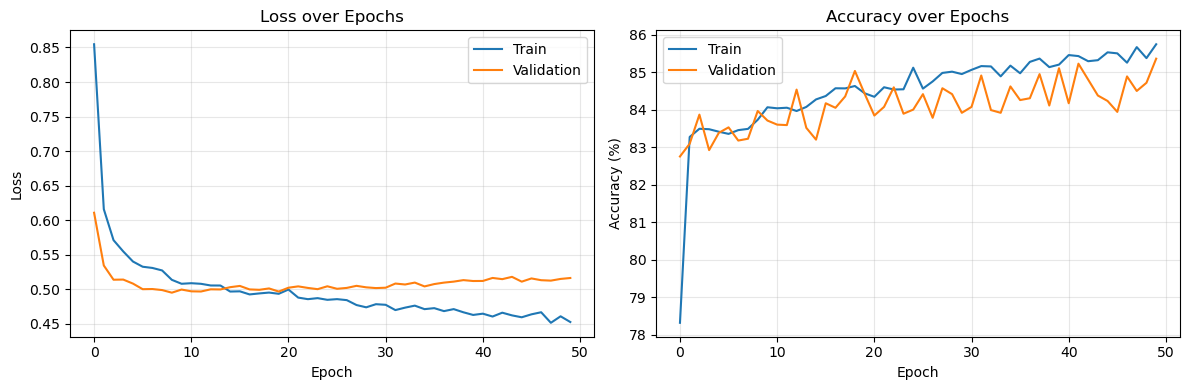

Reading the curves:
  Train loss dropping, val loss stable  → healthy learning
  Val loss rising while train drops      → overfitting
  Both plateaued together                → converged


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train')
axes[0].plot(val_losses,   label='Validation')
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([a * 100 for a in train_accs], label='Train')
axes[1].plot([a * 100 for a in val_accs],   label='Validation')
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Reading the curves:')
print('  Train loss dropping, val loss stable  → healthy learning')
print('  Val loss rising while train drops      → overfitting')
print('  Both plateaued together                → converged')

## Step 7: XGBoost

XGBoost builds trees **sequentially** — each new tree corrects the mistakes of all previous trees using gradient descent. Random Forest builds trees independently and averages them. That sequential correction is why XGBoost tends to win on tabular data.

Key parameter: `scale_pos_weight` = negatives / positives. Same idea as `class_weight='balanced'` in sklearn and `pos_weight` in the neural net — tells the model that missing a subscriber is more costly than a false alarm.

If you don't have it: `pip install xgboost`

In [13]:
import sys
!{sys.executable} -m pip install xgboost


  Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-macosx_12_0_arm64.whl (2.3 MB)


In [14]:
from xgboost import XGBClassifier

# scale_pos_weight is XGBoost's equivalent of class_weight='balanced'
# and pos_weight in the neural net — same ratio: negatives / positives
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
)
xgb.fit(X_train_scaled, y_train)
xgb_preds = xgb.predict(X_test_scaled)

print('=== XGBoost ===')
print(classification_report(y_test, xgb_preds, target_names=['No', 'Yes']))

=== XGBoost ===
              precision    recall  f1-score   support

          No       0.99      0.86      0.92      7310
         Yes       0.45      0.94      0.61       928

    accuracy                           0.87      8238
   macro avg       0.72      0.90      0.77      8238
weighted avg       0.93      0.87      0.88      8238



## Step 8: Compare All Four Models

The real question: which model earned its complexity?

In [15]:
# Collect neural net predictions
model.eval()
all_logits = []
with torch.no_grad():
    for X_batch, _ in test_loader:
        logits = model(X_batch.to(device))
        all_logits.append(logits.cpu())

nn_probs = torch.sigmoid(torch.cat(all_logits)).numpy()
nn_preds = (nn_probs > 0.5).astype(int)

for name, preds in [
    ('Logistic Regression',  lr_preds),
    ('Random Forest',        rf_preds),
    ('Neural Network (MLP)', nn_preds),
    ('XGBoost',              xgb_preds),
]:
    print(f'=== {name} ===')
    print(classification_report(y_test, preds, target_names=['No', 'Yes']))

=== Logistic Regression ===
              precision    recall  f1-score   support

          No       0.99      0.86      0.92      7310
         Yes       0.45      0.91      0.60       928

    accuracy                           0.87      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.87      0.88      8238

=== Random Forest ===
              precision    recall  f1-score   support

          No       0.93      0.98      0.95      7310
         Yes       0.71      0.42      0.52       928

    accuracy                           0.92      8238
   macro avg       0.82      0.70      0.74      8238
weighted avg       0.90      0.92      0.91      8238

=== Neural Network (MLP) ===
              precision    recall  f1-score   support

          No       0.99      0.84      0.91      7310
         Yes       0.43      0.93      0.59       928

    accuracy                           0.85      8238
   macro avg       0.71      0.89      0.75      

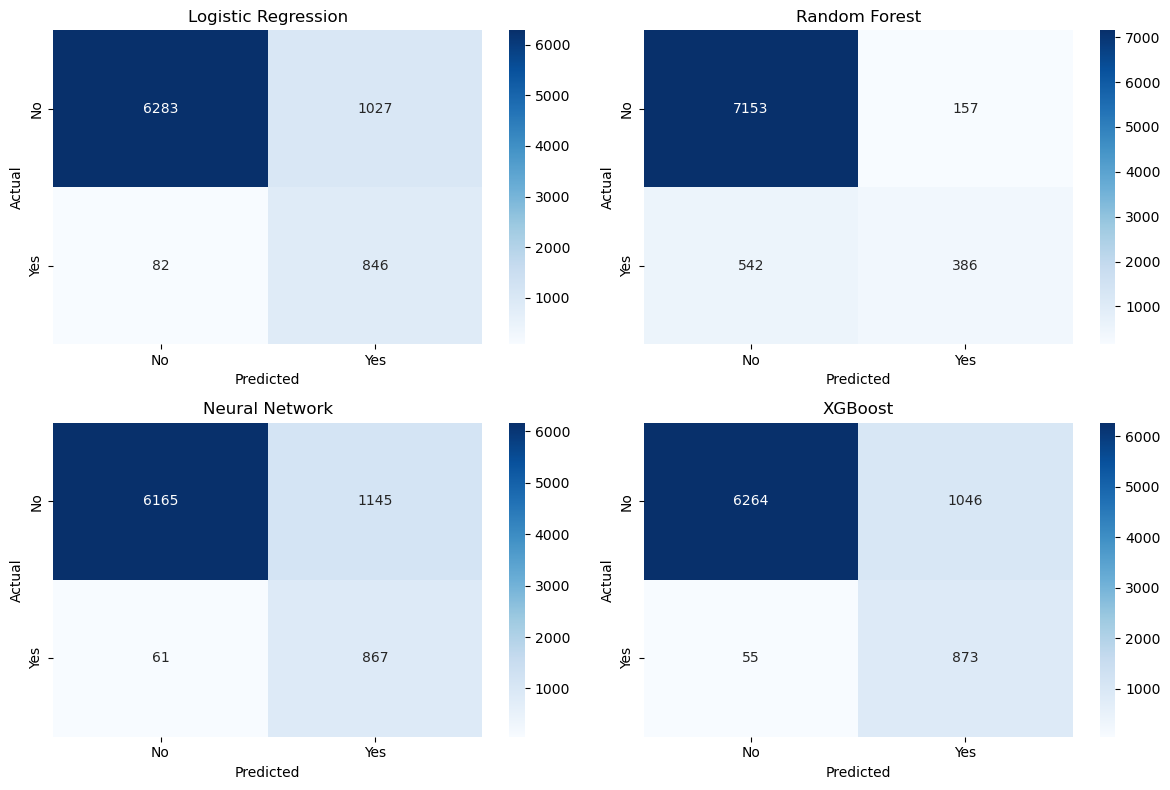

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, preds, title in zip(
    axes,
    [lr_preds, rf_preds, nn_preds, xgb_preds],
    ['Logistic Regression', 'Random Forest', 'Neural Network', 'XGBoost']
):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No', 'Yes'],
                yticklabels=['No', 'Yes'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## What You Built

A complete tabular classification pipeline with three model tiers:

1. **Downloaded** the UCI Bank Marketing dataset (41k rows, 20 features)
2. **Explored** class imbalance and categorical feature structure
3. **Encoded** categoricals with one-hot encoding, converted `pdays` to a binary indicator
4. **Scaled** with `StandardScaler` — a requirement for neural nets
5. **Trained** two sklearn baselines for comparison
6. **Built** a PyTorch `Dataset` + `DataLoader` for mini-batch training
7. **Designed** an MLP with `BatchNorm` and `Dropout` for regularization
8. **Trained** the network and tracked loss/accuracy curves over 50 epochs
9. **Compared** all three models side-by-side

## The Honest Result

On clean tabular data at this scale (~40k rows), Random Forest typically matches or beats a plain MLP. Neural networks pull ahead when:
- You have millions of rows
- Features have complex, high-order interactions
- You use **entity embeddings** for categoricals instead of one-hot (a much richer representation)

## Things to Try

1. **Drop `duration`** — it's a data leak (you can't know call length before making the call). How much does performance drop without it?
2. **Tune the decision threshold** — try `nn_probs > 0.3` instead of 0.5. More subscribers caught, but more false alarms. When is that trade-off worth it?
3. **Add a third hidden layer** — does a deeper net help or overfit?
4. **Try XGBoost** — `from xgboost import XGBClassifier`. Often the toughest baseline to beat on tabular data
5. **Try entity embeddings** — replace one-hot columns with `nn.Embedding` layers and learn dense representations for each categorical. This is how modern tabular nets (TabNet, NODE) outperform trees